### 1. Import necessary libraries

In [1]:
import os, sys, h5py, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
from __future__ import annotations


### 2. Check activations for all layers

In [7]:
PROJECT_ROOT = Path("/Users/pushpita/Documents/ML_Projects/AI_Safety/emotion-mechanisms-llm")
DATA_ROOT = Path("/Users/pushpita/Documents/ML_Projects/AI_Safety/emotion-mechanisms-llm/results")

data_dir = DATA_ROOT / "qwen_v2/activations_32b.h5"

# Peek into the structure of the HDF5 file to understand how the data is organized
with h5py.File(data_dir, "r") as f_in:
    print("Inside emotional:", list(f_in["emotional"].keys()))
    print("Inside emotions [Eg. Angry]:", list(f_in["emotional"]["angry"].keys()))
    print("Inside neutral:", list(f_in["neutral"].keys()))

Inside emotional: ['afraid', 'angry', 'calm', 'desperate', 'guilty', 'happy', 'inspired', 'loving', 'nervous', 'proud', 'sad', 'surprised']
Inside emotions [Eg. Angry]: ['layer_0', 'layer_1', 'layer_10', 'layer_11', 'layer_12', 'layer_13', 'layer_14', 'layer_15', 'layer_16', 'layer_17', 'layer_18', 'layer_19', 'layer_2', 'layer_20', 'layer_21', 'layer_22', 'layer_23', 'layer_24', 'layer_25', 'layer_26', 'layer_27', 'layer_28', 'layer_29', 'layer_3', 'layer_30', 'layer_31', 'layer_32', 'layer_33', 'layer_34', 'layer_35', 'layer_36', 'layer_37', 'layer_38', 'layer_39', 'layer_4', 'layer_40', 'layer_41', 'layer_42', 'layer_43', 'layer_44', 'layer_45', 'layer_46', 'layer_47', 'layer_48', 'layer_49', 'layer_5', 'layer_50', 'layer_51', 'layer_52', 'layer_53', 'layer_54', 'layer_55', 'layer_56', 'layer_57', 'layer_58', 'layer_59', 'layer_6', 'layer_60', 'layer_61', 'layer_62', 'layer_63', 'layer_7', 'layer_8', 'layer_9']
Inside neutral: ['layer_0', 'layer_1', 'layer_10', 'layer_11', 'layer_12

In [8]:
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

### 3. Open the file, read and save the activations for further analysis

##### Initialize the EmotionVectorExtractor

In [9]:
from emotion_mechanisms.vectors import EmotionVectorExtractor
import emotion_mechanisms.config as cfg

activations_path = data_dir
layer_indices = list(range(64))
emotions_extractor = EmotionVectorExtractor(activations_path=activations_path, 
                                    layer_indices=layer_indices)

In [10]:
my_activations = emotions_extractor.load_activations()
print("First Layer Emotional Activation Keys:", emotions_extractor.activations[0]["emotional"].keys())

print("First Layer Emotional Activation value shapes:", {emotion: values.shape
        for emotion, values in emotions_extractor.activations[0]["emotional"].items()})
print("First Layer Neutral Activation Shape:", emotions_extractor.activations[0]["neutral"].shape)

First Layer Emotional Activation Keys: dict_keys(['happy', 'inspired', 'loving', 'proud', 'calm', 'desperate', 'angry', 'afraid', 'nervous', 'guilty', 'sad', 'surprised'])
First Layer Emotional Activation value shapes: {'happy': (600, 5120), 'inspired': (600, 5120), 'loving': (600, 5120), 'proud': (600, 5120), 'calm': (600, 5120), 'desperate': (600, 5120), 'angry': (600, 5120), 'afraid': (600, 5120), 'nervous': (600, 5120), 'guilty': (600, 5120), 'sad': (600, 5120), 'surprised': (600, 5120)}
First Layer Neutral Activation Shape: (600, 5120)


### 4. Define a method for PCA denoising

In [11]:
cleaned_emotions_by_layer = {}
for layer in layer_indices:
    cleaned_emotions_by_layer[layer] = emotions_extractor.pca_denoise(layer=layer)

Layer 0: Retaining 39 PCA components to preserve 50.0% variance
Layer 1: Retaining 36 PCA components to preserve 50.0% variance
Layer 2: Retaining 32 PCA components to preserve 50.0% variance
Layer 3: Retaining 31 PCA components to preserve 50.0% variance
Layer 4: Retaining 1 PCA components to preserve 50.0% variance
Layer 5: Retaining 1 PCA components to preserve 50.0% variance
Layer 6: Retaining 1 PCA components to preserve 50.0% variance
Layer 7: Retaining 1 PCA components to preserve 50.0% variance
Layer 8: Retaining 1 PCA components to preserve 50.0% variance
Layer 9: Retaining 1 PCA components to preserve 50.0% variance
Layer 10: Retaining 1 PCA components to preserve 50.0% variance
Layer 11: Retaining 1 PCA components to preserve 50.0% variance
Layer 12: Retaining 1 PCA components to preserve 50.0% variance
Layer 13: Retaining 1 PCA components to preserve 50.0% variance
Layer 14: Retaining 1 PCA components to preserve 50.0% variance
Layer 15: Retaining 1 PCA components to preser

### 5. Plot them!!! 

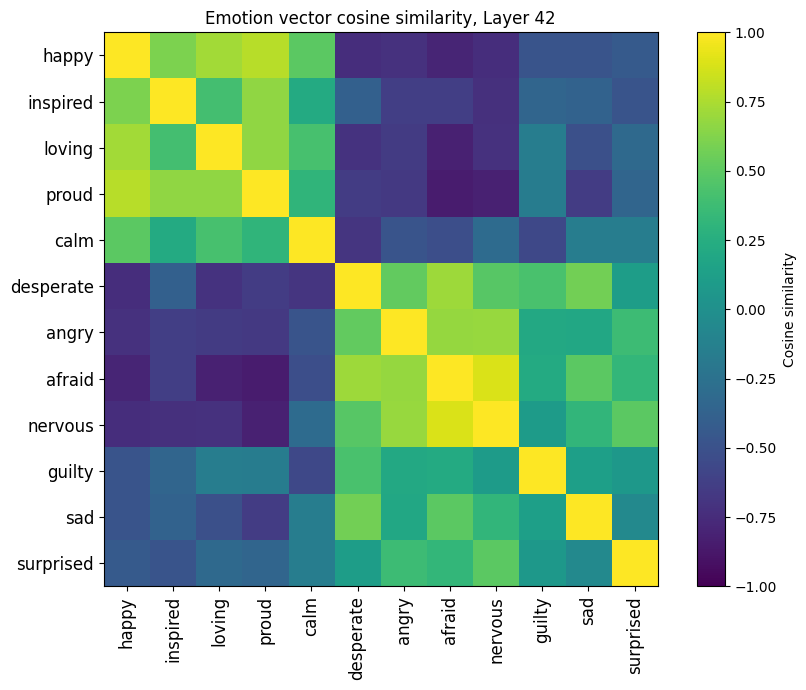

In [12]:
emotions = list(cleaned_emotions_by_layer[42].keys())
V = np.stack([cleaned_emotions_by_layer[42][emotion] for emotion in emotions])

cos_sim = cosine_similarity(V)

plt.figure(figsize=(9, 7))
plt.imshow(cos_sim, vmin=-1, vmax=1)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(emotions)), emotions, rotation=90, fontsize=12)
plt.yticks(range(len(emotions)), emotions, fontsize=12)
plt.title(f"Emotion vector cosine similarity, Layer 42", fontsize=12)
plt.tight_layout()
plt.show()

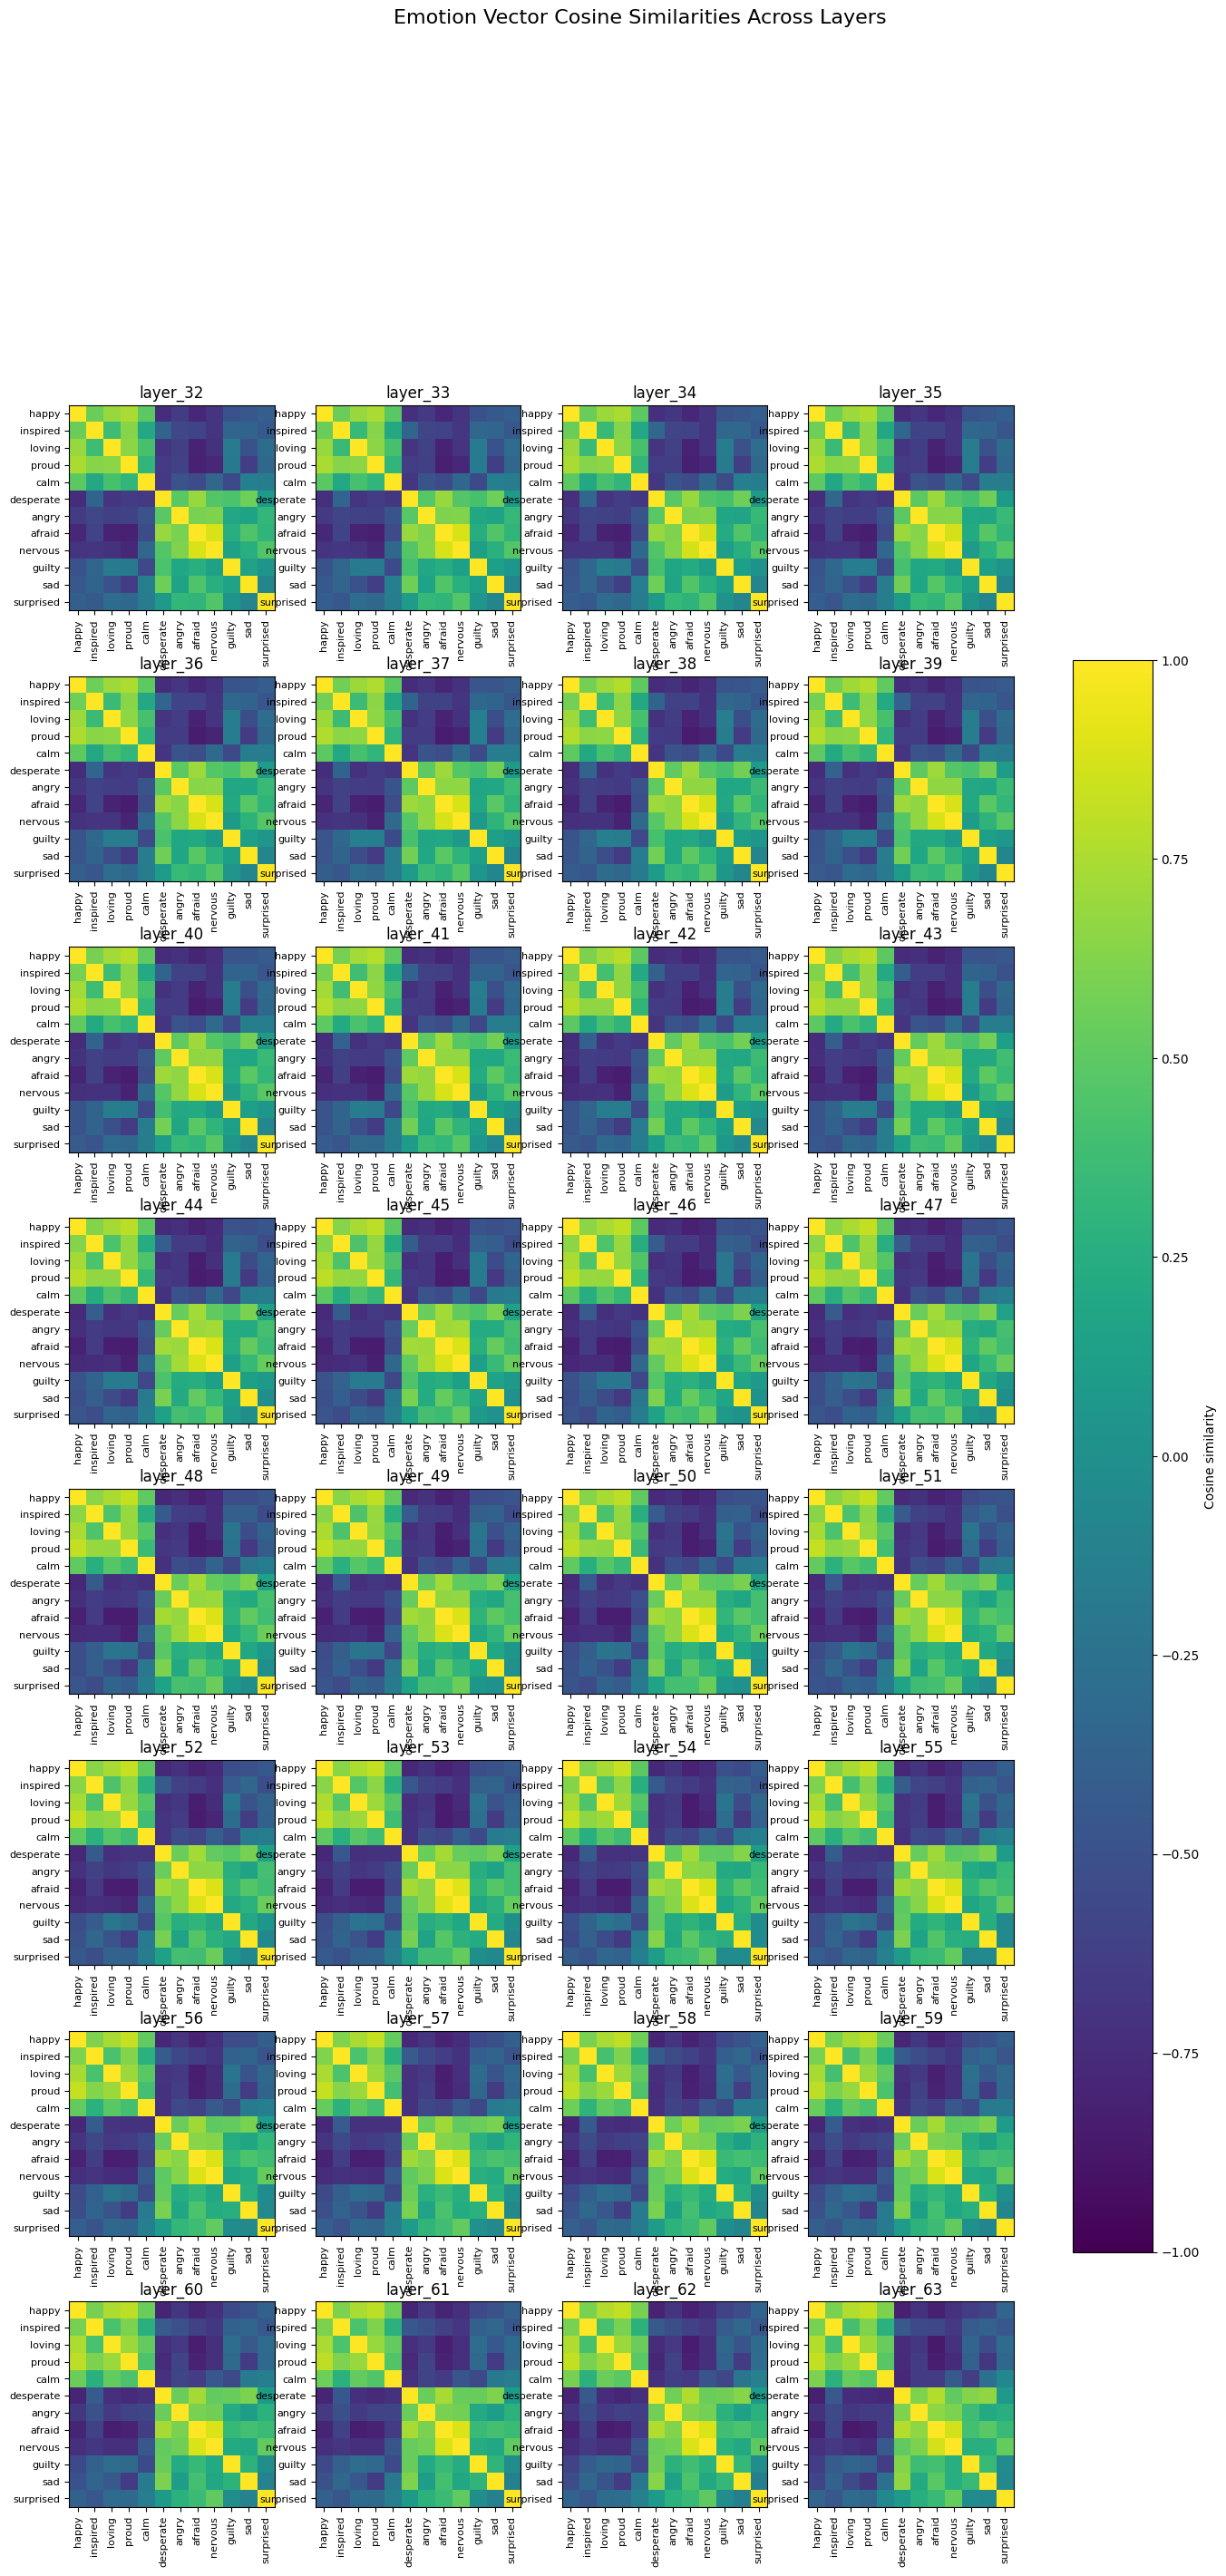

In [13]:
emotions = cfg.EMOTIONS

with h5py.File(data_dir, "r") as f_in:
    layers_to_plot = sorted(
        f_in["neutral"].keys(),
        key=lambda name: int(name.replace("layer_", "")),
    )
layers_to_plot = layers_to_plot[32:]
n_layers = len(layers_to_plot)
n_cols = min(4, n_layers)
n_rows = int(np.ceil(n_layers / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows), squeeze=False)

last_im = None
for ax, layer_name in zip(axes.flat, layers_to_plot):
    layer_idx = int(layer_name.replace("layer_", ""))
    V = np.stack([cleaned_emotions_by_layer[layer_idx][e] for e in emotions])
    cos_sim = cosine_similarity(V)
    last_im = ax.imshow(cos_sim, vmin=-1, vmax=1)
    ax.set_title(layer_name, fontsize=12)
    ax.set_xticks(range(len(emotions)))
    ax.set_yticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=90, fontsize=8)
    ax.set_yticklabels(emotions, fontsize=8)

for ax in axes.flat[n_layers:]:
    ax.axis("off")

fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.75, label="Cosine similarity")
fig.suptitle("Emotion Vector Cosine Similarities Across Layers", fontsize=16, y=1.02)
plt.show()

Explained variance ratio: [0.5534177  0.12658451]
Total variance explained: 0.6800022


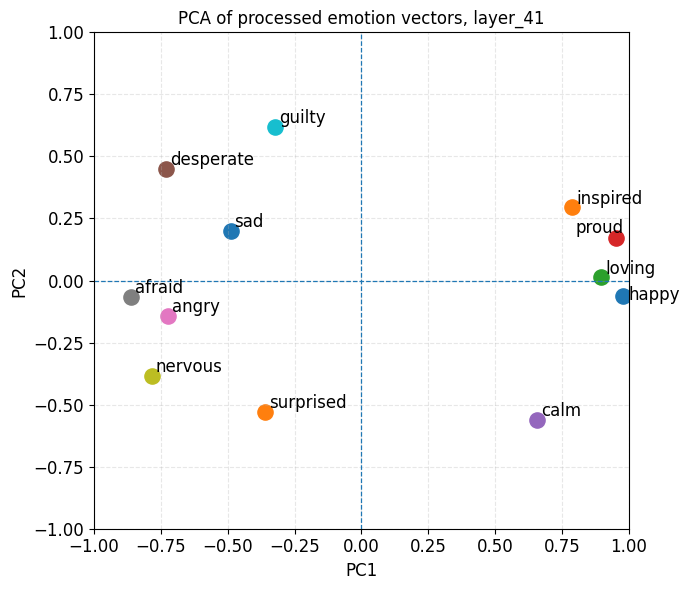

In [15]:
inspect_layer = layers_to_plot[9]
cleaned_emotions = cleaned_emotions_by_layer[int(inspect_layer.replace("layer_", ""))]

# Stack emotion vectors
emotions = list(cleaned_emotions.keys())
V = np.stack([cleaned_emotions[e] for e in emotions])

# PCA to 2D
pca = PCA(n_components=2)
V_2d = pca.fit_transform(V)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(7, 6))

for i, emotion in enumerate(emotions):
    x, y = V_2d[i]
    plt.scatter(x, y, s=120)
    if emotion not in ["happy", "proud"]:
        plt.text(x + 0.015, y + 0.015, emotion, fontsize=12)
    elif emotion == "proud":
        plt.text(x - 0.15, y + 0.02, emotion, fontsize=12)
    else:
        plt.text(x + 0.02, y - 0.018, emotion, rotation=0, fontsize=12)


plt.axhline(0, linewidth=0.9, linestyle="--")
plt.axvline(0, linewidth=0.9, linestyle="--")

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title(f"PCA of processed emotion vectors, {inspect_layer}", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### And it works!!!!!

### 6. Identifying the best layer for emotion vectors

In [ ]:
import emotion_mechanisms.vectors as vectors
vectors.main(activations_path=activations_path, layer_indices=layer_indices)

### 7. Plotting the additional emotion vectors

In [26]:
from emotion_mechanisms.vectors import EmotionVectorExtractor
import emotion_mechanisms.config as cfg

ADDITIONAL_EMOTIONS = [
    "deferential",
    "conflict_avoidant",
    "socially_anxious",
    "ashamed",
    "approval_seeking",
    "people_pleasing",
    "validation_seeking",
    "submissive",
    "obsequious"
]

activations_path = DATA_ROOT / "qwen_v2/activations_additionalemotions_32b.h5"

cfg.EMOTIONS = ADDITIONAL_EMOTIONS
cfg.CONFLICT_AVOIDANCE_EMOTIONS = ADDITIONAL_EMOTIONS
cfg.ALL_EMOTIONS = ADDITIONAL_EMOTIONS

layer_indices = list(range(20, 58, 1))
emotions_extractor = EmotionVectorExtractor(activations_path=activations_path, 
                                        layer_indices=layer_indices)

In [ ]:
my_activations = emotions_extractor.load_activations()
print("First Layer Emotional Activation Keys:", emotions_extractor.activations[0]["emotional"].keys())

print("First Layer Emotional Activation value shapes:", {emotion: values.shape
        for emotion, values in emotions_extractor.activations[0]["emotional"].items()})
print("First Layer Neutral Activation Shape:", emotions_extractor.activations[0]["neutral"].shape)

In [30]:
cleaned_emotions_by_layer = {}
for layer in layer_indices:
    cleaned_emotions_by_layer[layer] = emotions_extractor.pca_denoise(layer=layer)

Layer 20: Retaining 1 PCA components to preserve 50.0% variance
Layer 21: Retaining 1 PCA components to preserve 50.0% variance
Layer 22: Retaining 1 PCA components to preserve 50.0% variance
Layer 23: Retaining 1 PCA components to preserve 50.0% variance
Layer 24: Retaining 1 PCA components to preserve 50.0% variance
Layer 25: Retaining 1 PCA components to preserve 50.0% variance
Layer 26: Retaining 1 PCA components to preserve 50.0% variance
Layer 27: Retaining 1 PCA components to preserve 50.0% variance
Layer 28: Retaining 1 PCA components to preserve 50.0% variance
Layer 29: Retaining 1 PCA components to preserve 50.0% variance
Layer 30: Retaining 1 PCA components to preserve 50.0% variance
Layer 31: Retaining 1 PCA components to preserve 50.0% variance
Layer 32: Retaining 1 PCA components to preserve 50.0% variance
Layer 33: Retaining 1 PCA components to preserve 50.0% variance
Layer 34: Retaining 1 PCA components to preserve 50.0% variance
Layer 35: Retaining 1 PCA components to 

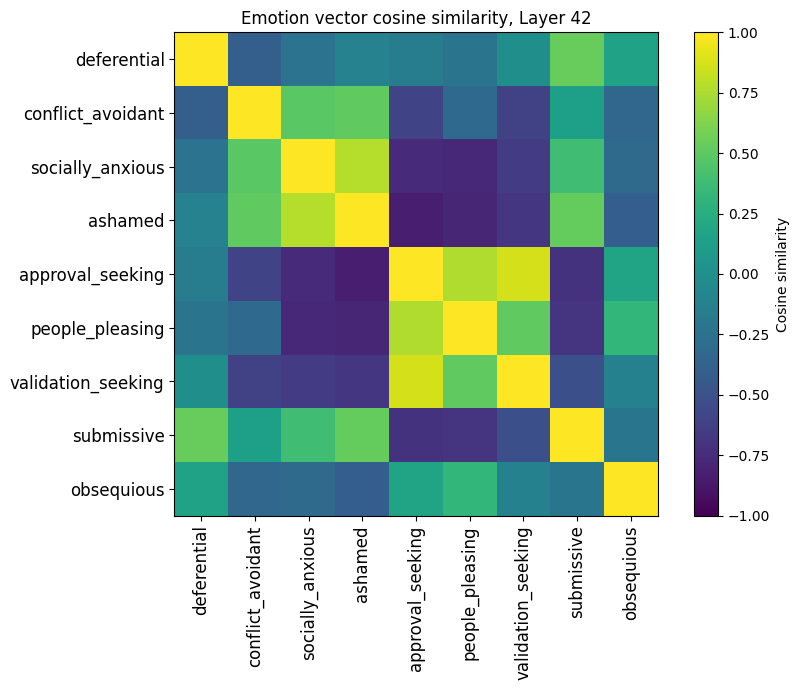

In [31]:
emotions = list(cleaned_emotions_by_layer[42].keys())
V = np.stack([cleaned_emotions_by_layer[42][emotion] for emotion in emotions])

cos_sim = cosine_similarity(V)

plt.figure(figsize=(9, 7))
plt.imshow(cos_sim, vmin=-1, vmax=1)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(emotions)), emotions, rotation=90, fontsize=12)
plt.yticks(range(len(emotions)), emotions, fontsize=12)
plt.title(f"Emotion vector cosine similarity, Layer 42", fontsize=12)
plt.tight_layout()
plt.show()

KeyError: 58

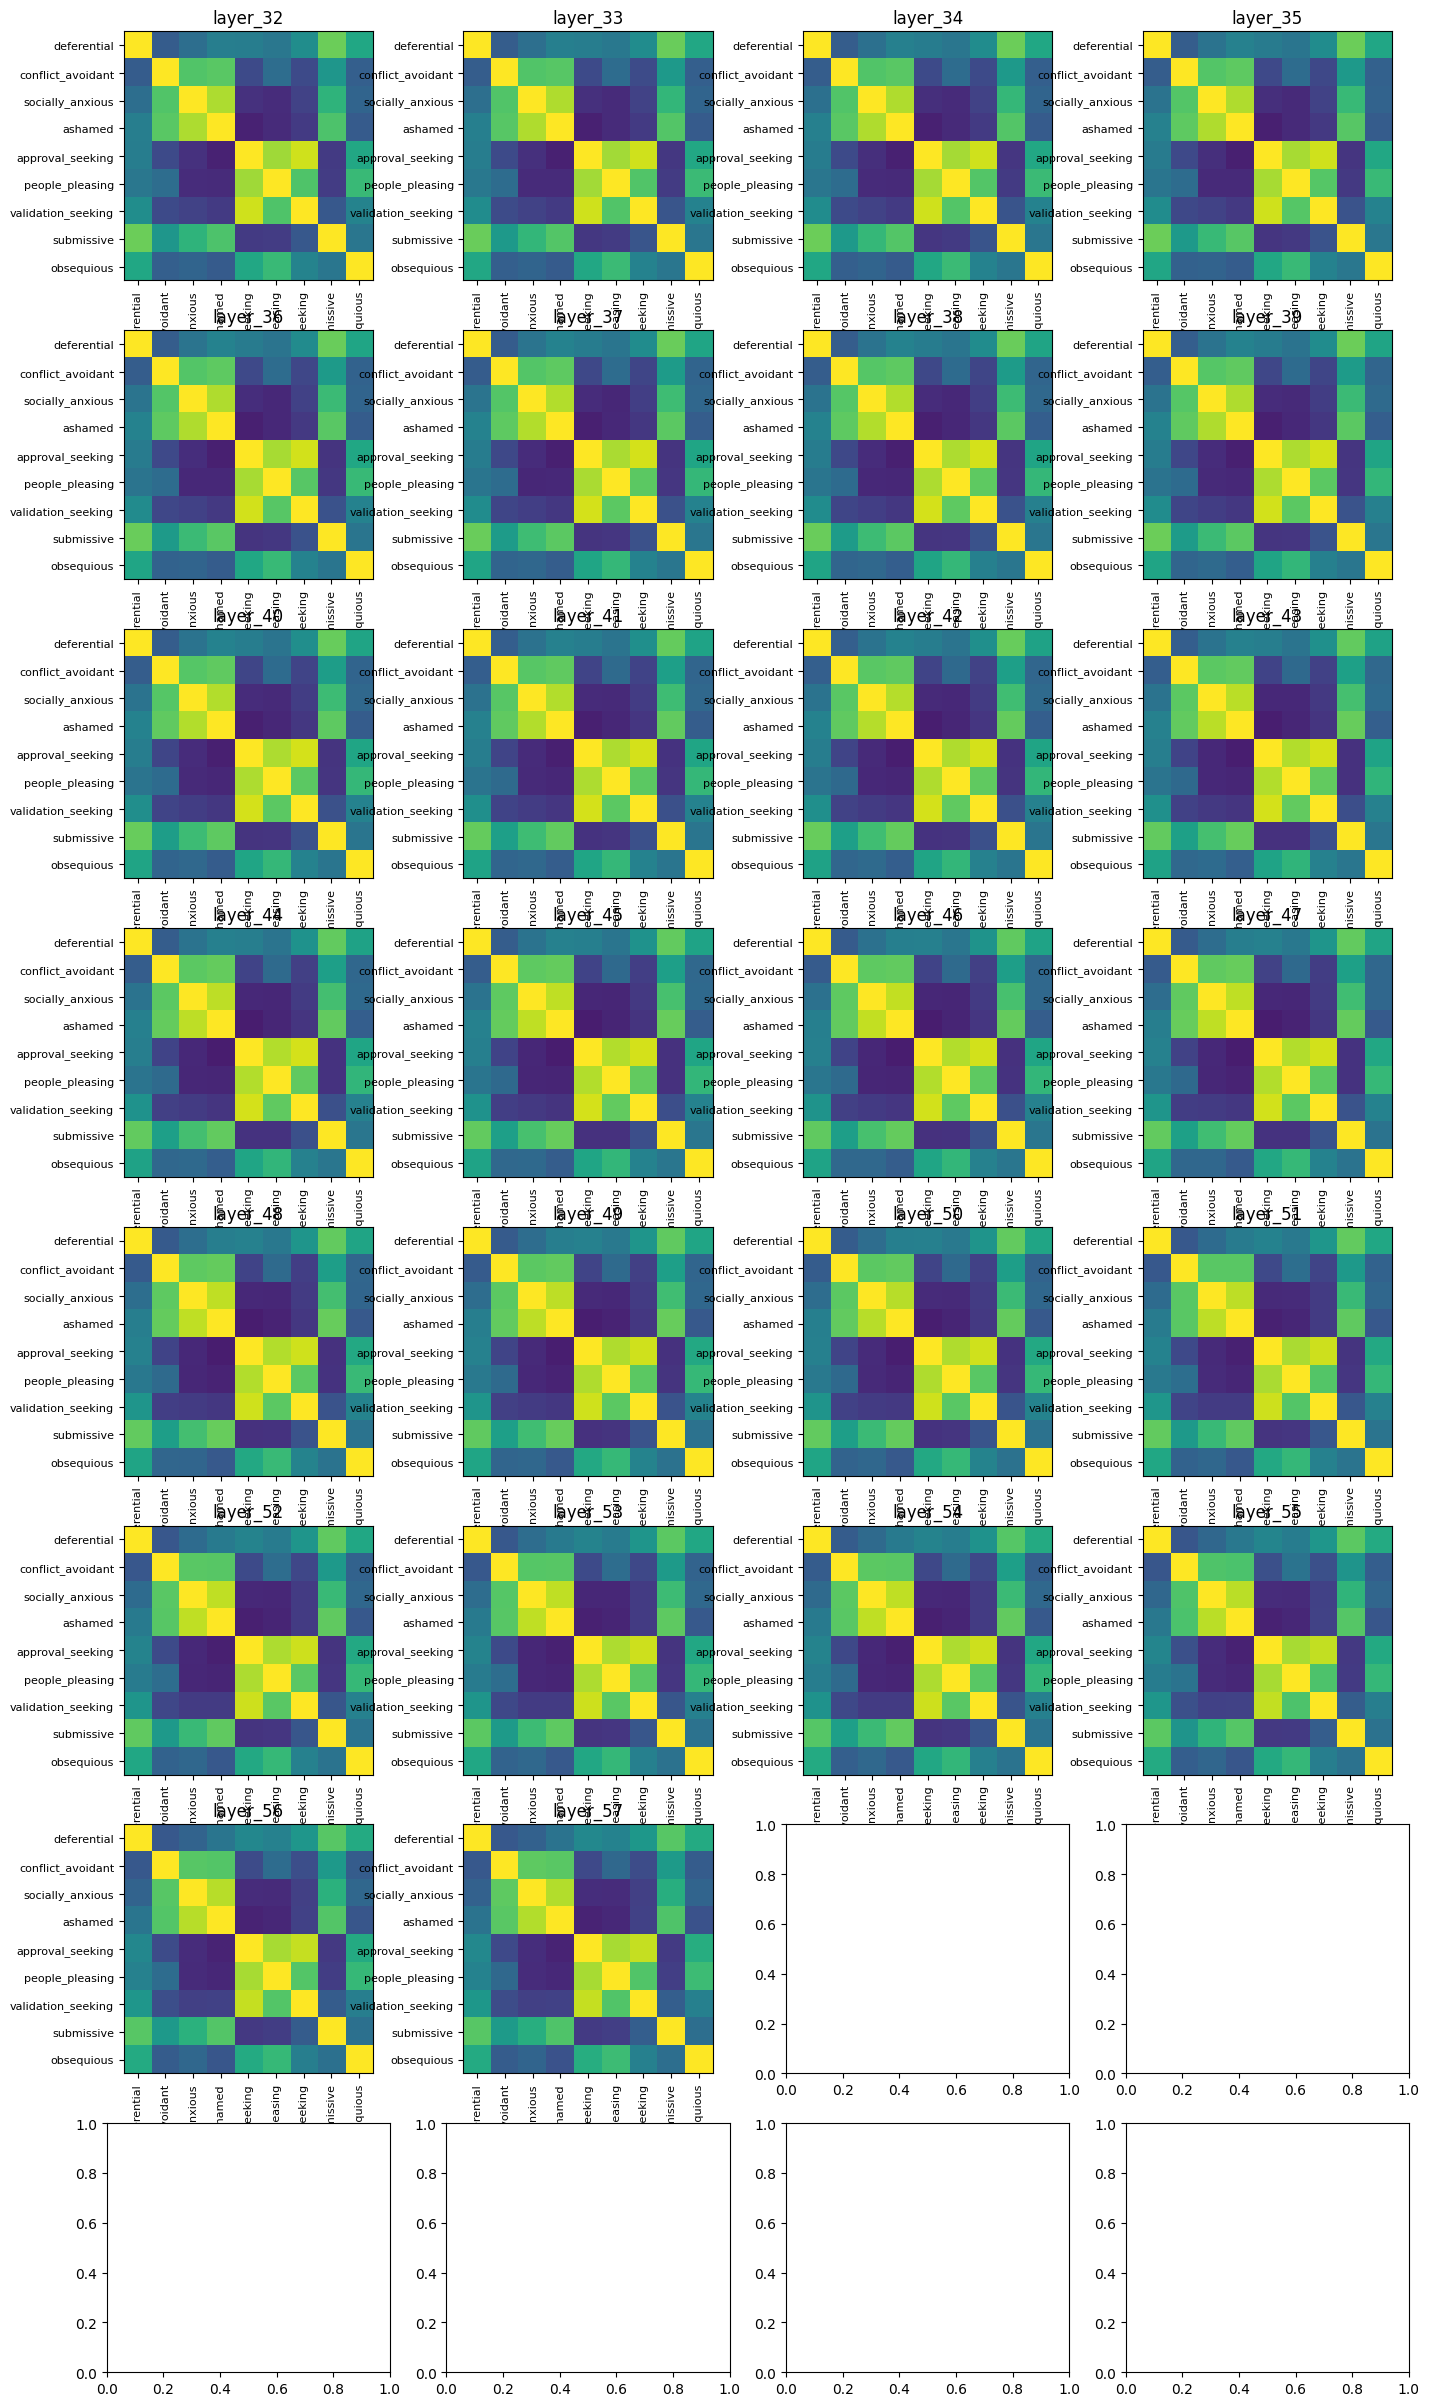

In [33]:
with h5py.File(data_dir, "r") as f_in:
    layers_to_plot = sorted(
        f_in["neutral"].keys(),
        key=lambda name: int(name.replace("layer_", "")),
    )
layers_to_plot = layers_to_plot[32:]
n_layers = len(layers_to_plot)
n_cols = min(4, n_layers)
n_rows = int(np.ceil(n_layers / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows), squeeze=False)

last_im = None
for ax, layer_name in zip(axes.flat, layers_to_plot):
    layer_idx = int(layer_name.replace("layer_", ""))
    V = np.stack([cleaned_emotions_by_layer[layer_idx][e] for e in emotions])
    cos_sim = cosine_similarity(V)
    last_im = ax.imshow(cos_sim, vmin=-1, vmax=1)
    ax.set_title(layer_name, fontsize=12)
    ax.set_xticks(range(len(emotions)))
    ax.set_yticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=90, fontsize=8)
    ax.set_yticklabels(emotions, fontsize=8)

for ax in axes.flat[n_layers:]:
    ax.axis("off")

fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.75, label="Cosine similarity")
fig.suptitle("Emotion Vector Cosine Similarities Across Layers", fontsize=16, y=1.02)
plt.show()

Explained variance ratio: [0.5426962  0.19376022]
Total variance explained: 0.7364564


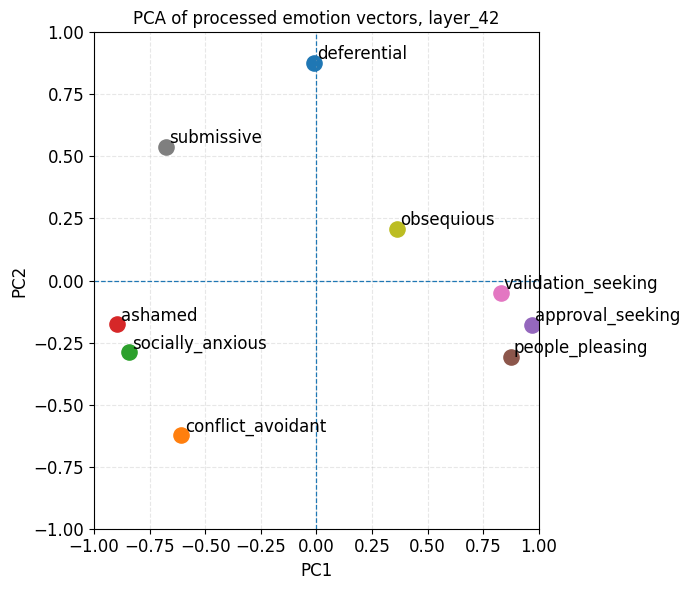

In [15]:
inspect_layer = "layer_42"
cleaned_emotions = cleaned_emotions_by_layer[int(inspect_layer.replace("layer_", ""))]

# Stack emotion vectors
emotions = list(cleaned_emotions.keys())
V = np.stack([cleaned_emotions[e] for e in emotions])

# PCA to 2D
pca = PCA(n_components=2)
V_2d = pca.fit_transform(V)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(7, 6))

for i, emotion in enumerate(emotions):
    x, y = V_2d[i]
    plt.scatter(x, y, s=120)
    if emotion not in ["happy", "proud"]:
        plt.text(x + 0.015, y + 0.015, emotion, fontsize=12)
    elif emotion == "proud":
        plt.text(x - 0.15, y + 0.02, emotion, fontsize=12)
    else:
        plt.text(x + 0.02, y - 0.018, emotion, rotation=0, fontsize=12)


plt.axhline(0, linewidth=0.9, linestyle="--")
plt.axvline(0, linewidth=0.9, linestyle="--")

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title(f"PCA of processed emotion vectors, {inspect_layer}", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### 8. Combined PCA: core emotions + additional emotions

This cell plots the original emotion set and the additional conflict-avoidance emotions in the same PCA space.


Layer 40: Retaining 1 PCA components to preserve 50.0% variance
Layer 40: Retaining 1 PCA components to preserve 50.0% variance
Explained variance ratio: [0.4822869  0.15208901]
Total variance explained: 0.63437593


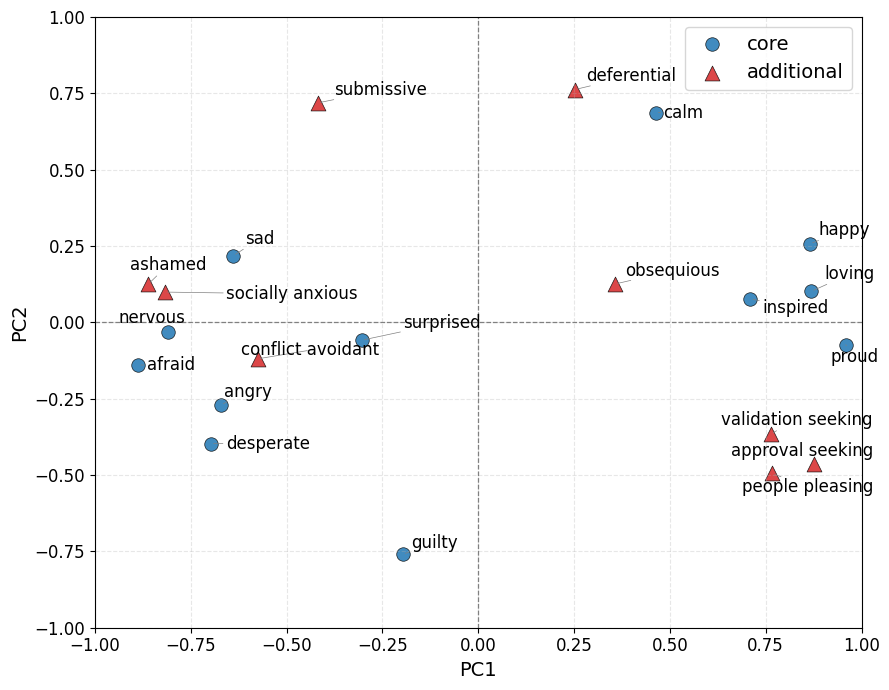

In [8]:
!pip install adjustText -q

from pathlib import Path
from sklearn.decomposition import PCA
from adjustText import adjust_text
import h5py
import numpy as np
import matplotlib.pyplot as plt

from emotion_mechanisms.vectors import EmotionVectorExtractor
import emotion_mechanisms.config as cfg

CORE_ACTIVATIONS_PATH = DATA_ROOT / "qwen_v2/activations/activations_32b.h5"
ADDITIONAL_ACTIVATIONS_PATH = DATA_ROOT / "qwen_v2/activations/activations_additionalemotions_32b.h5"
CORE_PCA_LAYER = 40
ADDITIONAL_PCA_LAYER = 40
PCA_VARIANCE_THRESHOLD = 0.50


def activation_emotions(activations_path: Path) -> list[str]:
    with h5py.File(activations_path, "r") as f:
        return list(f["emotional"].keys())


core_extractor = EmotionVectorExtractor(
    activations_path=CORE_ACTIVATIONS_PATH,
    layer_indices=[CORE_PCA_LAYER],
    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    emotions=activation_emotions(CORE_ACTIVATIONS_PATH),
)
core_extractor.load_activations()
core_dirs = core_extractor.pca_denoise(CORE_PCA_LAYER)

additional_extractor = EmotionVectorExtractor(
    activations_path=ADDITIONAL_ACTIVATIONS_PATH,
    layer_indices=[ADDITIONAL_PCA_LAYER],
    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    emotions=activation_emotions(ADDITIONAL_ACTIVATIONS_PATH),
)
additional_extractor.load_activations()
additional_dirs = additional_extractor.pca_denoise(ADDITIONAL_PCA_LAYER)

labels = list(core_dirs) + list(additional_dirs)
groups = (["core"] * len(core_dirs)) + (["additional"] * len(additional_dirs))
# Joint matrix of denoised vectors; reused by both PCA and UMAP below.
V = np.stack([*core_dirs.values(), *additional_dirs.values()])

pca = PCA(n_components=2)
V_2d = pca.fit_transform(V)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(9, 7))
styles = {
    "core":       {"marker": "o", "color": "tab:blue", "s": 95},
    "additional": {"marker": "^", "color": "tab:red",  "s": 115},
}

texts = []
for label, group, (x, y) in zip(labels, groups, V_2d):
    style = styles[group]
    ax.scatter(x, y, label=group, alpha=0.85, edgecolor="black", linewidth=0.5, **style)
    display_label = label.replace("_", " ")
    texts.append(ax.text(x, y, display_label, fontsize=12))

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    expand=(1.2, 1.5),
    force_text=(0.3, 0.5),
)

handles, legend_labels = ax.get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=14)

ax.axhline(0, linewidth=0.9, linestyle="--", color="gray")
ax.axvline(0, linewidth=0.9, linestyle="--", color="gray")
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
# ax.set_title(
#     "Combined PCA of Core and Additional Emotion Directions"
#     + "\n"
#     + f"Layer {CORE_PCA_LAYER}: Core + Additional Emotions"
# )
ax.grid(alpha=0.3, linestyle="--")
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()


In [17]:
import umap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use 4 clusters for the small joint core + additional emotion set.
FIG6_K = 4

# Fig. 6 style: cluster the denoised emotion directions, then visualize them jointly with UMAP.
kmeans = KMeans(n_clusters=FIG6_K, n_init=20, random_state=cfg.SEED)
cluster_ids = kmeans.fit_predict(V)

reducer = umap.UMAP(
    n_neighbors=3,
    min_dist=0.0,
    metric="cosine",
    random_state=cfg.SEED,
)
umap_2d = reducer.fit_transform(V)
umap_2d = StandardScaler().fit_transform(umap_2d)

plt.figure(figsize=(10, 8))
cmap = plt.get_cmap("tab10", FIG6_K)
markers = {"core": "o", "additional": "^"}

for label, group, cluster_id, (x, y) in zip(labels, groups, cluster_ids, umap_2d):
    plt.scatter(
        x,
        y,
        marker=markers[group],
        color=cmap(cluster_id),
        s=115 if group == "additional" else 95,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.5,
    )
    text = plt.text(x + 0.03, y + 0.03, label.replace("_", " "), fontsize=10, color="black")
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground="white"),
        path_effects.Normal(),
    ])

core_handle = plt.Line2D([], [], marker="o", linestyle="", color="black", label="core")
additional_handle = plt.Line2D([], [], marker="^", linestyle="", color="black", label="additional")
plt.legend(handles=[core_handle, additional_handle], fontsize=12, loc="best")

plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)
plt.title(
    f"Fig. 6-style UMAP of Denoised Emotion Directions, k-means k={FIG6_K}"
    + "\n"
    + f"Layer {CORE_PCA_LAYER}: Joint Core + Additional Emotions"
)
label_offsets = {
    "happy": (0.03, 0.05),
    "inspired": (-0.02, 0.06),
    "loving": (0.03, -0.02),
    "proud": (0.03, 0.02),
    "guilty": (-0.03, 0.04),
    "desperate": (0.02, 0.03),
    "sad": (0.03, -0.02),
}
dx, dy = label_offsets.get(label, (0.03, 0.03))
plt.text(x + dx, y + dy, label.replace("_", " "), fontsize=10)

plt.grid(alpha=0.25, linestyle="--")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Layer 38: Retaining 1 PCA components to preserve 50.0% variance
Layer 38: Retaining 1 PCA components to preserve 50.0% variance
Layer 39: Retaining 1 PCA components to preserve 50.0% variance
Layer 39: Retaining 1 PCA components to preserve 50.0% variance
Layer 40: Retaining 1 PCA components to preserve 50.0% variance
Layer 40: Retaining 1 PCA components to preserve 50.0% variance
Layer 41: Retaining 1 PCA components to preserve 50.0% variance
Layer 41: Retaining 1 PCA components to preserve 50.0% variance
Layer 42: Retaining 1 PCA components to preserve 50.0% variance
Layer 42: Retaining 1 PCA components to preserve 50.0% variance
Layer 43: Retaining 1 PCA components to preserve 50.0% variance
Layer 43: Retaining 1 PCA components to preserve 50.0% variance
Layer 44: Retaining 1 PCA components to preserve 50.0% variance
Layer 44: Retaining 1 PCA components to preserve 50.0% variance
Layer 45: Retaining 1 PCA components to preserve 50.0% variance
Layer 45: Retaining 1 PCA components to 

Probe directions layer 0:  25%|██▌       | 3/12 [20:44<58:40, 391.21s/emotion]  

Layer 47: Retaining 1 PCA components to preserve 50.0% variance
Layer 47: Retaining 1 PCA components to preserve 50.0% variance


Layer 48: Retaining 1 PCA components to preserve 50.0% variance
Layer 48: Retaining 1 PCA components to preserve 50.0% variance
Layer 49: Retaining 1 PCA components to preserve 50.0% variance
Layer 49: Retaining 1 PCA components to preserve 50.0% variance


Layer 50: Retaining 1 PCA components to preserve 50.0% variance
Layer 50: Retaining 1 PCA components to preserve 50.0% variance
Layer 51: Retaining 2 PCA components to preserve 50.0% variance
Layer 51: Retaining 2 PCA components to preserve 50.0% variance
Layer 52: Retaining 3 PCA components to preserve 50.0% variance
Layer 52: Retaining 3 PCA components to preserve 50.0% variance
Layer 53: Retaining 4 PCA components to preserve 50.0% variance
Layer 53: Retaining 4 PCA components to preserve 50.0% variance
Layer 54: Retaining 5 PCA components to preserve 50.0% variance
Layer 54: Retaining 5 PCA components to preserve 50.0% variance
Layer 55: Retaining 6 PCA components to preserve 50.0% variance
Layer 55: Retaining 6 PCA components to preserve 50.0% variance
Layer 56: Retaining 7 PCA components to preserve 50.0% variance
Layer 56: Retaining 7 PCA components to preserve 50.0% variance
Layer 57: Retaining 8 PCA components to preserve 50.0% variance
Layer 57: Retaining 8 PCA components to 

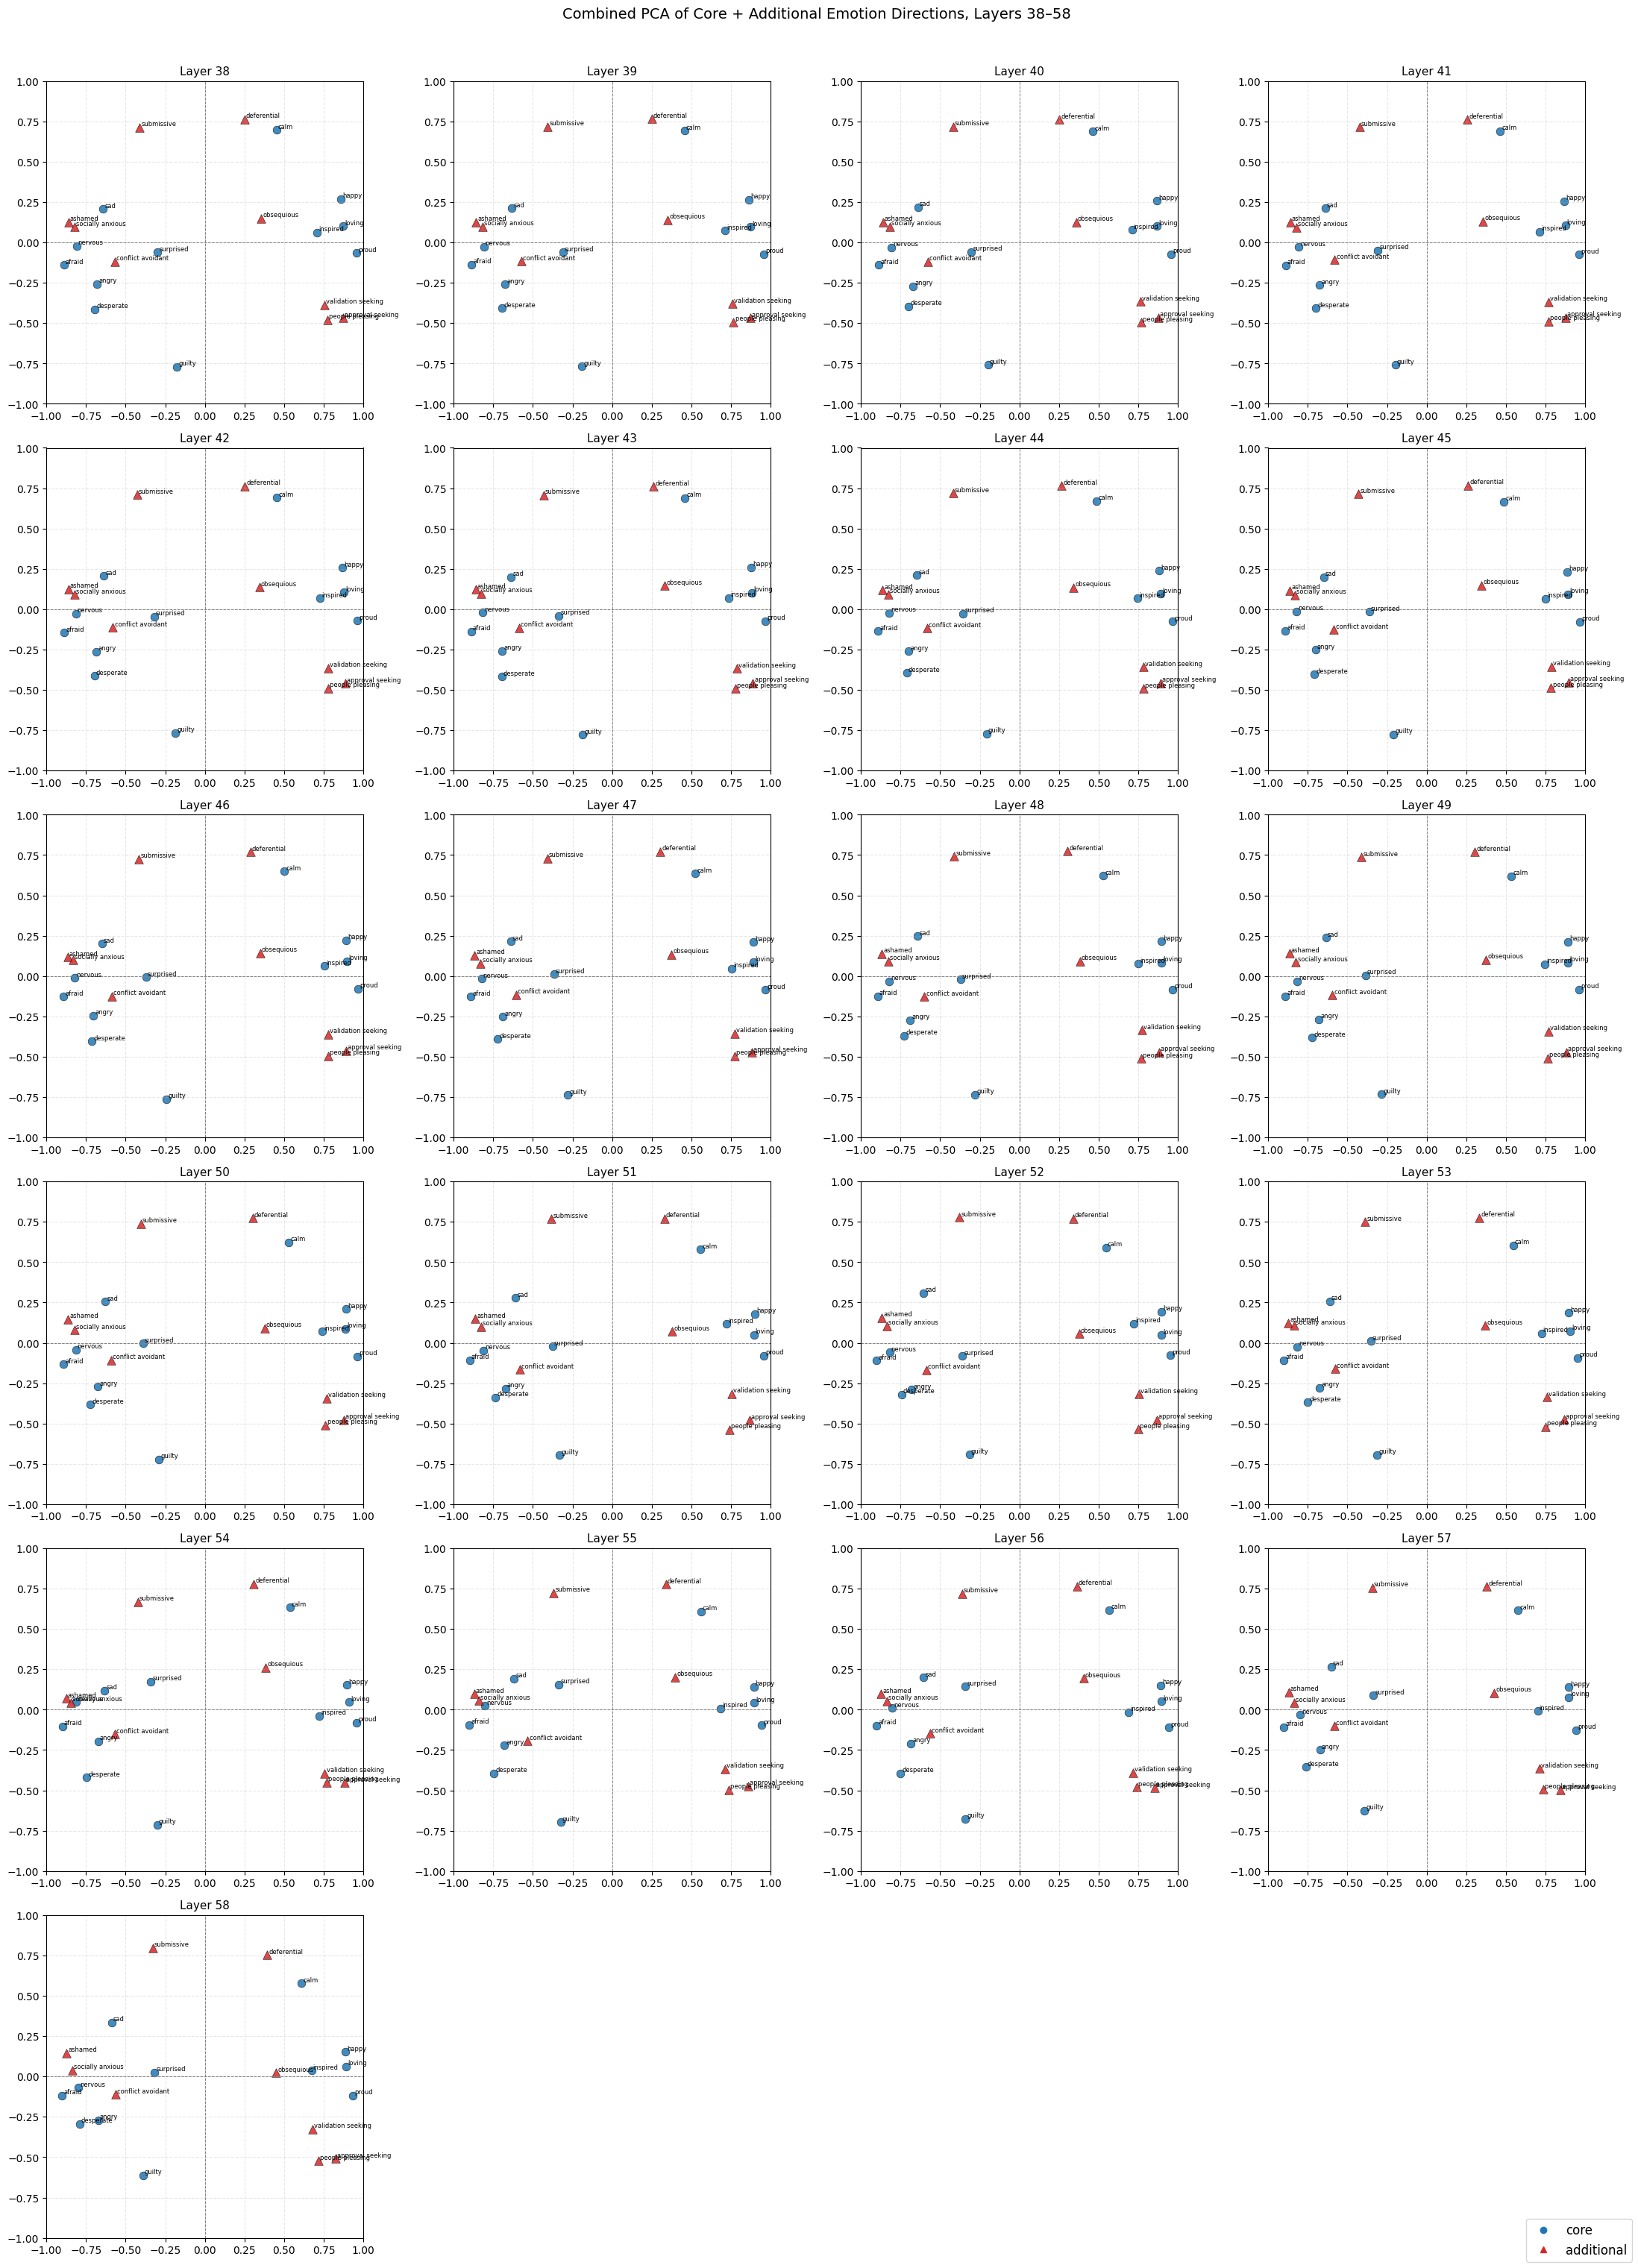












Probe directions layer 0:  33%|███▎      | 4/12 [27:08<51:47, 388.44s/emotion]



In [18]:
from matplotlib.lines import Line2D

LAYERS_TO_PLOT = list(range(38, 59))
N_COLS = 4
N_ROWS = int(np.ceil(len(LAYERS_TO_PLOT) / N_COLS))

core_extractor_sweep = EmotionVectorExtractor(
    activations_path=CORE_ACTIVATIONS_PATH,
    layer_indices=LAYERS_TO_PLOT,
    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    emotions=activation_emotions(CORE_ACTIVATIONS_PATH),
)
core_extractor_sweep.load_activations()

additional_extractor_sweep = EmotionVectorExtractor(
    activations_path=ADDITIONAL_ACTIVATIONS_PATH,
    layer_indices=LAYERS_TO_PLOT,
    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    emotions=activation_emotions(ADDITIONAL_ACTIVATIONS_PATH),
)
additional_extractor_sweep.load_activations()

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(5.5 * N_COLS, 5 * N_ROWS), squeeze=False)

styles = {
    "core":       {"marker": "o", "color": "tab:blue", "s": 60},
    "additional": {"marker": "^", "color": "tab:red",  "s": 70},
}

for ax, layer in zip(axes.flat, LAYERS_TO_PLOT):
    core_dirs_l       = core_extractor_sweep.pca_denoise(layer)
    additional_dirs_l = additional_extractor_sweep.pca_denoise(layer)

    labels_l = list(core_dirs_l) + list(additional_dirs_l)
    groups_l = ["core"] * len(core_dirs_l) + ["additional"] * len(additional_dirs_l)
    V_l = np.stack([*core_dirs_l.values(), *additional_dirs_l.values()])

    V_2d_l = PCA(n_components=2).fit_transform(V_l)

    for label, group, (x, y) in zip(labels_l, groups_l, V_2d_l):
        ax.scatter(x, y, alpha=0.85, edgecolor="black", linewidth=0.4, **styles[group])
        ax.text(x + 0.01, y + 0.01, label.replace("_", " "), fontsize=6)

    ax.axhline(0, linewidth=0.7, linestyle="--", color="gray")
    ax.axvline(0, linewidth=0.7, linestyle="--", color="gray")
    ax.set_title(f"Layer {layer}", fontsize=11)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.3, linestyle="--")

for ax in axes.flat[len(LAYERS_TO_PLOT):]:
    ax.axis("off")

legend_handles = [
    Line2D([], [], marker="o", linestyle="", color="tab:blue", label="core"),
    Line2D([], [], marker="^", linestyle="", color="tab:red",  label="additional"),
]
fig.legend(handles=legend_handles, fontsize=12, loc="lower right")
fig.suptitle("Combined PCA of Core + Additional Emotion Directions, Layers 38–58", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3D PCA plot of the original emotion set and the additional conflict-avoidance emotions.

Layer 40: Retaining 1 PCA components to preserve 50.0% variance
Layer 40: Retaining 1 PCA components to preserve 50.0% variance
Explained variance ratio: [0.48228678 0.15208898 0.10476408]
Total variance explained: 0.73913985


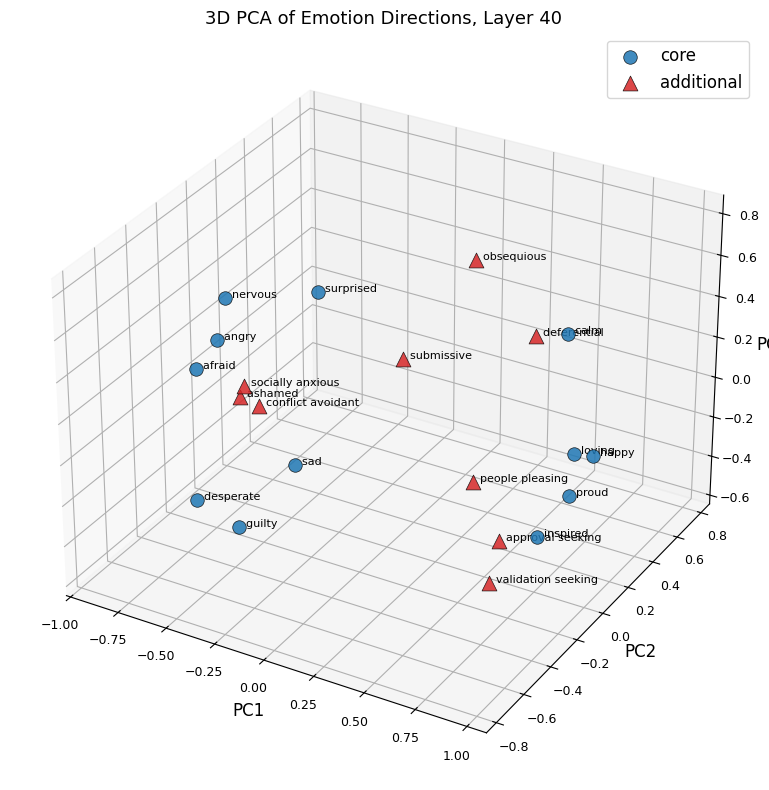

In [12]:
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from sklearn.decomposition import PCA
import h5py
import numpy as np
import matplotlib.pyplot as plt

from emotion_mechanisms.vectors import EmotionVectorExtractor
import emotion_mechanisms.config as cfg

CORE_ACTIVATIONS_PATH = DATA_ROOT / "qwen_v2/activations/activations_32b.h5"
ADDITIONAL_ACTIVATIONS_PATH = DATA_ROOT / "qwen_v2/activations/activations_additionalemotions_32b.h5"
CORE_PCA_LAYER = 40
ADDITIONAL_PCA_LAYER = 40
PCA_VARIANCE_THRESHOLD = 0.50


def activation_emotions(activations_path: Path) -> list[str]:
    with h5py.File(activations_path, "r") as f:
        return list(f["emotional"].keys())


core_extractor = EmotionVectorExtractor(
    activations_path=CORE_ACTIVATIONS_PATH,
    layer_indices=[CORE_PCA_LAYER],
    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    emotions=activation_emotions(CORE_ACTIVATIONS_PATH),
)
core_extractor.load_activations()
core_dirs = core_extractor.pca_denoise(CORE_PCA_LAYER)

additional_extractor = EmotionVectorExtractor(
    activations_path=ADDITIONAL_ACTIVATIONS_PATH,
    layer_indices=[ADDITIONAL_PCA_LAYER],
    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    emotions=activation_emotions(ADDITIONAL_ACTIVATIONS_PATH),
)
additional_extractor.load_activations()
additional_dirs = additional_extractor.pca_denoise(ADDITIONAL_PCA_LAYER)

labels = list(core_dirs) + list(additional_dirs)
groups = (["core"] * len(core_dirs)) + (["additional"] * len(additional_dirs))
V = np.stack([*core_dirs.values(), *additional_dirs.values()])

pca = PCA(n_components=3)
V_3d = pca.fit_transform(V)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

styles = {
    "core":       {"marker": "o", "color": "tab:blue", "s": 95},
    "additional": {"marker": "^", "color": "tab:red",  "s": 115},
}

seen_groups = set()
for label, group, (x, y, z) in zip(labels, groups, V_3d):
    style = styles[group]
    ax.scatter(x, y, z,
               label=group if group not in seen_groups else "_nolegend_",
               alpha=0.85, edgecolor="black", linewidth=0.5, **style)
    seen_groups.add(group)
    ax.text(x, y, z, "  " + label.replace("_", " "), fontsize=8)

ax.set_xlabel("PC1", fontsize=12)
ax.set_ylabel("PC2", fontsize=12)
ax.set_zlabel("PC3", fontsize=12)
ax.set_title(f"3D PCA of Emotion Directions, Layer {CORE_PCA_LAYER}", fontsize=13)
ax.tick_params(labelsize=9)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [13]:
import plotly.graph_objects as go
from IPython.display import HTML, display

# V_3d, labels, groups already computed in the cell above
color_map = {"core": "royalblue", "additional": "tomato"}
symbol_map = {"core": "circle", "additional": "diamond"}

fig_3d = go.Figure()

for group in ["core", "additional"]:
    mask = [g == group for g in groups]
    xs = V_3d[mask, 0]
    ys = V_3d[mask, 1]
    zs = V_3d[mask, 2]
    lbls = [l.replace("_", " ") for l, m in zip(labels, mask) if m]

    fig_3d.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="markers+text",
        name=group,
        text=lbls,
        textposition="top center",
        textfont=dict(size=11),
        marker=dict(
            size=7,
            symbol=symbol_map[group],
            color=color_map[group],
            opacity=0.85,
            line=dict(color="black", width=0.5),
        ),
    ))

fig_3d.update_layout(
    title=f"3D PCA of Emotion Directions — Layer {CORE_PCA_LAYER} (drag to rotate)",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    legend=dict(font=dict(size=13)),
    width=850,
    height=700,
)

display(HTML(fig_3d.to_html(include_plotlyjs="cdn", full_html=False)))
